In [8]:
import torch
import numpy as np

from dinosaw.helpers import add_custom_font, get_models, get_features, model_names, ModelTypes

from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
DEVICE = 'cuda:0'

In [9]:
enabled_models = ('dv2', 'dvt', 'alibi_dv2_coco', 'dv3', 'alibi_dv3')

models = get_models(enabled_models, '../../trained_models', DEVICE, conf_path='../../dinov3')

In [10]:
image_fnames = ['diff_shapes_518.png', 'wuppertal.jpg', '000004.jpg']
imgs: list[Image.Image] = []
ks = [4, 5, 3]
results: dict[ModelTypes, list[np.ndarray]] = {mt: [] for mt in enabled_models}

In [11]:
for img_fname in image_fnames:
    img = Image.open(f'../paper_figures/data/PCA/{img_fname}').convert('RGB')
    img = img.resize((518, 518))
    imgs.append(img)

In [12]:
%%capture
for key, model in models.items():
    for i, img in enumerate(imgs):
        feats_li = []
        feats = get_features(model, img, True, False, device=DEVICE)
        h, w, c = feats.shape
        flat = feats.reshape((h * w, c))
        flat = scale(flat)
        reduced = KMeans(ks[i], n_init=15).fit_predict(flat)
        reduced_2D = reduced.reshape((h, w))
        results[key].append(reduced_2D)

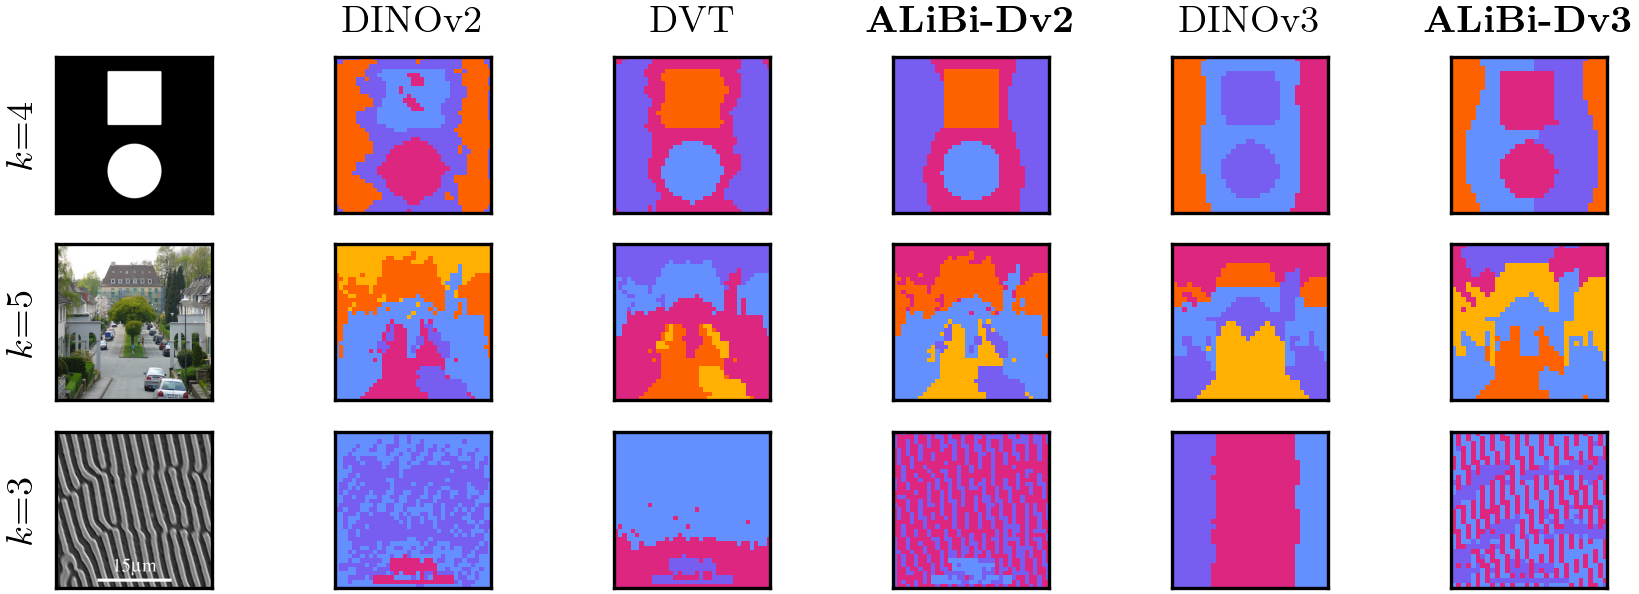

In [13]:
# %%capture
plt.style.use("thesis.mplstyle")
from skimage.color import label2rgb
from PIL.ImageColor import getcolor

COLOURS = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000"
]
COLORS = [[v / 255.0 for v in getcolor(c, "RGB")] for c in COLOURS]


W, H = 7, 2.3

N_COLS = len(image_fnames)
N_ROWS = len(enabled_models) + 1

fig, axs = plt.subplots(N_COLS, N_ROWS, figsize=(W, H))

for i, img in enumerate(imgs):
    ax = axs[i, 0]
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_ylabel(r'$k$' + rf"={ks[i]}")

    for j, key in enumerate(enabled_models):
        ax = axs[i, j + 1,]
        selected_ch = results[key][i]
        remapped = label2rgb(selected_ch, colors=COLORS, bg_label=-1)
        ax.imshow(remapped, cmap='tab10')
        ax.set_xticks([])
        ax.set_yticks([])            

        if i == 0:
            model_name = model_names[key]
            model_name = model_name.replace('(COCO)', '')
            model_name = rf"\textbf{{{model_name}}}" if 'ALiBi' in model_name else model_name
            axs[0, j+ 1].set_title(model_name,)
# plt.tight_layout()

# plt.savefig('saved/04.png', dpi=300)
plt.savefig("out/k_means.pdf", dpi=300, bbox_inches='tight')